<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


#### Import the required libraries we need for the lab.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [2]:
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [3]:
boston_df

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,9.67,22.4
502,502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,9.08,20.6
503,503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,5.64,23.9
504,504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,6.48,22.0


---

## Task 1: Understanding the Boston Housing Dataset


| Variable    | What it Means (Simple Explanation)                                                                   |
| ----------- | ---------------------------------------------------------------------------------------------------- |
| **CRIM**    | Crime rate in the town — higher means more crime per person                                          |
| **ZN**      | How much land is zoned for **big houses** —      **Bigger number = more big houses with big yards**  |
| **INDUS**   | (factories, warehouses)           **Bigger number = more business land in the town.**                |
| **CHAS**    | Dummy variable: Is the house next to the **Charles River**? 1 means yes, 0 means no                  |
| **NOX**     | Level of **nitric oxide pollution** in the air **Bigger number = more pollution**                    |
| **RM**      | Average number of rooms in each house —                 **bigger houses have more rooms**            |
| **AGE**     | shows how old the neighborhood is                   **Bigger number = more old houses in the town.** |
| **DIS**     | How far the neighborhood is from                         **Bigger number = farther from work.**      |
| **RAD**     | How easy it is to get to the                        **Bigger number = easier to get on highways.**   |
| **TAX**     | Tax rate paid for the house 💰 — how much tax is charged per property **Bigger number = higher tax.**|
| **PTRATIO** | Number of students per teacher in schools 👩‍🏫 — **lower usually means better education quality**      |
| **LSTAT**   | % of people with low income or poor jobs 👥 (e.g., low income) **Bigger number = more poor people.** |
| **MEDV**    | Median (middle) price of houses in thousands of dollars 💵   — **our target variable** (house price) |


---

## Task 2: Descriptive Statistics and Visualizations

### 📦 Boxplot of Median Home Values (MEDV)

This boxplot shows the range of house prices (`MEDV`) in the dataset.  
- The **line inside the box** is the **median** (middle price).  
- The **top and bottom of the box** show where most house prices fall.  
- Any **dots outside the box** are **outliers** — these are houses with prices much higher or lower than most others.  

This helps us understand if most houses are cheap or expensive, and how spread out the prices are.


/home/mirr/Desktop/amir/data_SC/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


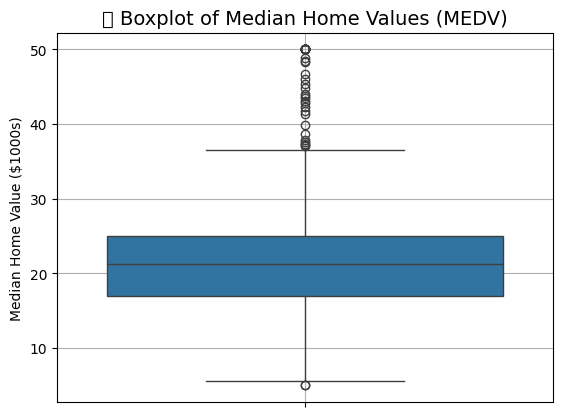

In [4]:
sns.boxplot(y=boston_df['MEDV'])
plt.title('📦 Boxplot of Median Home Values (MEDV)', fontsize=14)
plt.ylabel('Median Home Value ($1000s)')
plt.grid(True)
plt.show()

### 🏞️ Bar Plot of Charles River Variable (CHAS)

This bar plot shows how many houses are **near the Charles River** and how many are not.  
- `CHAS = 1` means the house is next to the river.  
- `CHAS = 0` means the house is not near the river.

This helps us understand how many homes are located in riverfront areas versus other areas.  
It’s useful because we will later test whether being near the river affects house prices.


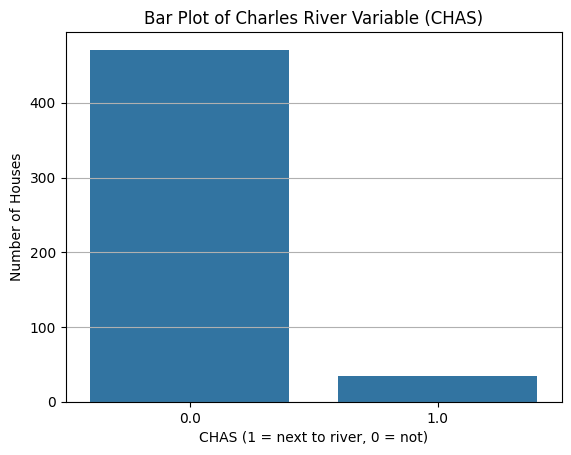

In [5]:
sns.countplot(x=boston_df['CHAS'])
plt.title("Bar Plot of Charles River Variable (CHAS)")
plt.xlabel("CHAS (1 = next to river, 0 = not)")
plt.ylabel("Number of Houses")
plt.grid(True, axis='y')
plt.show()

### 🏠 Boxplot of Median Home Value (MEDV) by Age Group of Houses

In this chart, the `AGE` variable (which shows how old the houses are) has been divided into **three groups**:

- 🟢 `<=35 yrs`: Newer houses  
- 🟡 `35–70 yrs`: Middle-aged houses  
- 🔴 `70+ yrs`: Older houses

We use a boxplot to compare **house prices (MEDV)** between these 3 age groups.

- The **line inside the box** shows the **median (middle) price**.  
- The size of the box shows how spread out the prices are.  
- Dots outside the boxes are **outliers** (very high or low prices).

👉 This helps us see if newer homes are more expensive or cheaper than older ones.


/home/mirr/Desktop/amir/data_SC/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


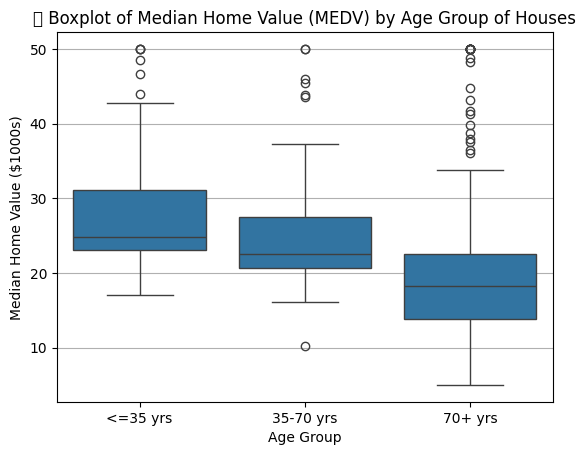

In [6]:
# Create age groups
boston_df['age_group'] = pd.cut(boston_df['AGE'], 
                               bins=[0, 35, 70, 100], 
                               labels=['<=35 yrs', '35-70 yrs', '70+ yrs'])

# Create boxplot
sns.boxplot(x=boston_df['age_group'], y=boston_df['MEDV'])
plt.title('🏠 Boxplot of Median Home Value (MEDV) by Age Group of Houses')
plt.xlabel('Age Group')
plt.ylabel('Median Home Value ($1000s)')
plt.grid(True, axis='y')
plt.show()

### 🌫️ Scatter Plot: Nitric Oxide Concentration (NOX) vs Industrial Land (INDUS)

This scatter plot shows the relationship between air pollution (NOX) and the amount of land used for factories or businesses (INDUS).  
- The **x-axis** shows the percentage of industrial land.  
- The **y-axis** shows the level of pollution.  

If the dots tend to go up together (positive trend), it means more industrial land may cause more pollution.


/home/mirr/Desktop/amir/data_SC/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127787 (\N{FOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


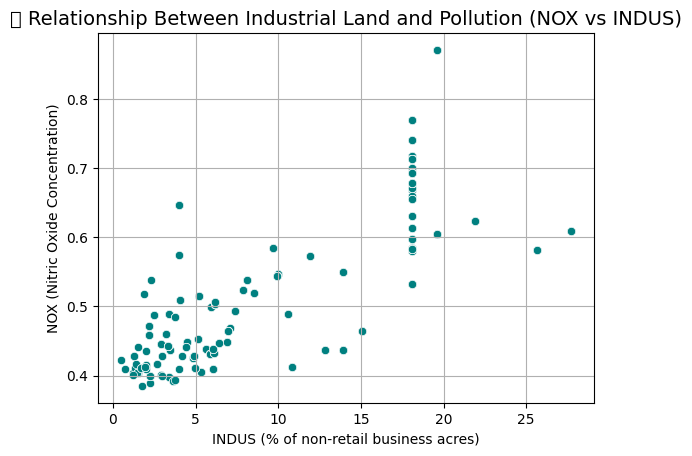

In [7]:
sns.scatterplot(x='INDUS', y='NOX', data=boston_df, color='teal')
plt.title(
    '🌫️ Relationship Between Industrial Land and Pollution (NOX vs INDUS)', fontsize=14)
plt.xlabel('INDUS (% of non-retail business acres)')
plt.ylabel('NOX (Nitric Oxide Concentration)')
plt.grid(True)
plt.show()

### 📚 Histogram of Pupil-Teacher Ratio (PTRATIO)

This histogram shows how many towns have different pupil-to-teacher ratios in schools.  
- The x-axis shows the ratio (number of students per teacher).  
- The y-axis shows how many towns have that ratio.  

It helps us understand what the most common class sizes are across towns.


/home/mirr/Desktop/amir/data_SC/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


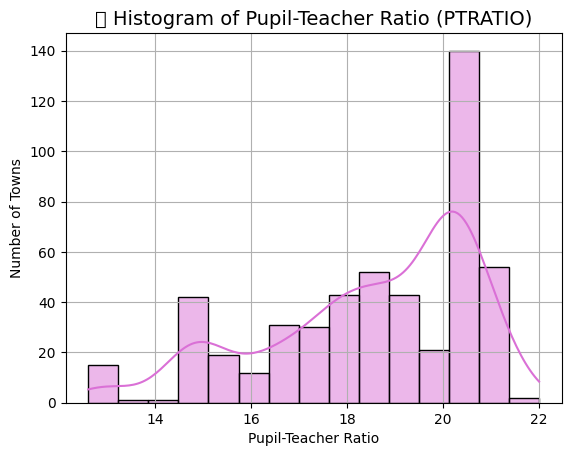

In [8]:
sns.histplot(boston_df['PTRATIO'], bins=15, kde=True, color='orchid')
plt.title('📚 Histogram of Pupil-Teacher Ratio (PTRATIO)', fontsize=14)
plt.xlabel('Pupil-Teacher Ratio')
plt.ylabel('Number of Towns')
plt.grid(True)
plt.show()

---

## Task 3: Statistical Analysis

### 🏞️ T-Test: Does being near the Charles River affect house prices?

We used an independent samples T-test to compare home prices (`MEDV`) between:

- Houses near the Charles River (`CHAS = 1`)  
- Houses not near the river (`CHAS = 0`)  

If the **p-value is less than 0.05**, we reject the null hypothesis and say there's a significant difference.

This helps us know if **location near water** impacts housing value in Boston.


#### 1. Hypotheses
    - **Null Hypothesis (H₀):**  
    There is **no difference** in median home values between houses near the Charles River and those not near it.

    - **Alternative Hypothesis (H₁):**  
    There **is a difference** in median home values between the two groups.

We will test this using α = 0.05.

the T-test:

In [10]:
from scipy.stats import ttest_ind

# Split MEDV into two groups based on CHAS
medv_river = boston_df[boston_df['CHAS'] == 1]['MEDV']     # Houses near the river
medv_nonriver = boston_df[boston_df['CHAS'] == 0]['MEDV']  # Houses not near the river

# Perform independent t-test
t_stat, p_value = ttest_ind(medv_river, medv_nonriver)

# Print results
print("🎯 T-Test: MEDV vs CHAS (River Proximity)")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Interpret result
alpha = 0.05
if p_value < alpha:
    print("✅ There is a significant difference in house prices based on Charles River location.")
else:
    print("❌ No significant difference in house prices based on Charles River location.")

🎯 T-Test: MEDV vs CHAS (River Proximity)
T-Statistic: 3.9964
P-Value: 0.0001
✅ There is a significant difference in house prices based on Charles River location.


### 🧓 ANOVA: Does the age of the house affect the price?

We split the `AGE` variable (age of houses) into 3 groups:

- `<=35 yrs` (newer houses)  
- `35–70 yrs` (middle-aged houses)  
- `70+ yrs` (older houses)

Then we used an **ANOVA test** to compare the median house values (`MEDV`) across these groups.

If the **p-value is less than 0.05**, we reject the null hypothesis and say that at least one group has a different price.


#### 1. Hypotheses

    **Null Hypothesis (H₀):**  
    There is **no difference** in median home values between age groups.

    **Alternative Hypothesis (H₁):**  
    There **is a difference** in median home values among at least one age group.

We use α = 0.05.

In [11]:
from scipy.stats import f_oneway

# Make sure AGE_GROUP column is created
bins = [0, 35, 70, 100]
labels = ['<=35 yrs', '35-70 yrs', '70+ yrs']
boston_df['AGE_GROUP'] = pd.cut(boston_df['AGE'], bins=bins, labels=labels)

# Split MEDV by age group
group1 = boston_df[boston_df['AGE_GROUP'] == '<=35 yrs']['MEDV']
group2 = boston_df[boston_df['AGE_GROUP'] == '35-70 yrs']['MEDV']
group3 = boston_df[boston_df['AGE_GROUP'] == '70+ yrs']['MEDV']

# Perform ANOVA
f_stat, p_value = f_oneway(group1, group2, group3)

# Print results
print("📊 ANOVA: MEDV by AGE_GROUP")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("✅ There is a significant difference in house prices among age groups.")
else:
    print("❌ No significant difference in house prices among age groups.")

📊 ANOVA: MEDV by AGE_GROUP
F-Statistic: 36.4076
P-Value: 0.0000
✅ There is a significant difference in house prices among age groups.


### 🌫️ Pearson Correlation: Is there a link between pollution and industrial land?

We used the **Pearson correlation** to measure the relationship between:

- `NOX` (nitric oxide pollution)  
- `INDUS` (industrial land usage)  

If the **p-value is less than 0.05**, we reject the null hypothesis and say there’s a **significant correlation**.

The **correlation coefficient** (value between -1 and 1) tells us:
- Close to +1: Strong positive relationship
- Close to -1: Strong negative relationship
- Around 0: No linear relationship
#### 1. Hypotheses

    **Null Hypothesis (H₀):**  
    There is **no correlation** between pollution and industrial land usage.

    **Alternative Hypothesis (H₁):**  
    There **is a correlation** between pollution and industrial land usage.

In [14]:
from scipy.stats import pearsonr

# Calculate correlation between NOX and INDUS
corr_coef, p_value = pearsonr(boston_df['NOX'], boston_df['INDUS'])

# Show the results
print("🔗 Pearson Correlation: NOX vs INDUS")
print(f"Correlation Coefficient: {corr_coef:.4f}")
print(f"P-Value: {p_value:.4f}")

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("✅ There is a significant relationship between industrial land and pollution.")
else:
    print("❌ No significant relationship between industrial land and pollution.")

🔗 Pearson Correlation: NOX vs INDUS
Correlation Coefficient: 0.7637
P-Value: 0.0000
✅ There is a significant relationship between industrial land and pollution.


### 🏙️ Regression: Does distance to jobs affect house prices?

We ran a **regression analysis** to see if the distance to employment centers (`DIS`) affects house prices (`MEDV`).

- `X` = DIS (distance to 5 employment centers)
- `y` = MEDV (median house price)

If the **p-value for DIS is less than 0.05**, then distance significantly affects price.

The **coefficient of DIS** tells us the direction:
- Positive → farther homes are more expensive
- Negative → farther homes are cheaper
#### 1. Hypotheses

    **Null Hypothesis (H₀):**  
    Distance to employment centers does not affect house prices.

    **Alternative Hypothesis (H₁):**  
    Distance to employment centers does affect house prices.

We'll use α = 0.05

In [15]:
import statsmodels.api as sm

# Define independent (X) and dependent (y) variables
X = sm.add_constant(boston_df['DIS'])  # Adds an intercept to the model
y = boston_df['MEDV']

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print the summary
print("🏙️ Regression Analysis: Distance to Employment Centers vs House Prices")
print(model.summary())

🏙️ Regression Analysis: Distance to Employment Centers vs House Prices
                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Tue, 15 Jul 2025   Prob (F-statistic):           1.21e-08
Time:                        07:08:03   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------